# Compute MI(φ/ψ; Z) + attention pooling importance → pick 2 CVs

Questo notebook è **autonomo**: non assume che `mi_phi_psi_vs_latent.csv` esista.

È però **consistente con il tuo progetto**:
- usa gli stessi file di output del run (`latents.npy`, `attn_weights.npy`, `token_residue_ids.txt`)
- usa (se disponibile) la funzione del progetto per i diedri `pkgs.utils.compute_aligned_phi_psi(...)`
- stima la MI con `sklearn.feature_selection.mutual_info_regression` come nel tuo notebook MI
- seleziona 2 CV con penalità di ridondanza **basata sui time-series dei due angoli** (quindi richiede traiettoria/topologia)

---

## Input richiesti
Nel run output folder (es. `test05/output/`):
- `latents.npy` (T×d)
- `attn_weights.npy` (T×N)
- `token_residue_ids.txt` (N)

Per ricavare φ/ψ:
- Trajectory (es. `traj.xtc` / `traj.dcd`) + Topology (es. `top.pdb` / `top.gro`)


In [35]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.feature_selection import mutual_info_regression

try:
    import mdtraj as md
    MDTraj_AVAILABLE = True
except Exception:
    MDTraj_AVAILABLE = False

print("MDTraj available:", MDTraj_AVAILABLE)


MDTraj available: True


In [36]:
# -----------------------
# CONFIG (EDIT THESE PATHS)
# -----------------------
OUTPUT_DIR = Path("../test08/output")   # <-- cambia qui

LATENTS_PATH = OUTPUT_DIR / "latents.npy"
ATTN_WEIGHTS_PATH = OUTPUT_DIR / "attn_weights.npy"
TOKEN_RESIDUES_PATH = OUTPUT_DIR / "token_residue_ids.txt"

TRAJ_PATH = Path("../../data/traj_skip100NoH.xtc")
TOP_PATH  = Path("../../data/2JOF-0-proteinNoH.pdb")

MI_N_NEIGHBORS = 100
RANDOM_STATE = 0
MI_NORMALIZE_BY_LATENT_DIM = True

ALPHA = 0.7        # mix MI vs attention (come prima)
GAMMA = 0.35       # peso alpha-likeness (nuovo; 0.2–0.6 tipico)
LAMBDA = 0.8
TOPK = 50

print("OUTPUT_DIR:", OUTPUT_DIR.resolve())
for p in [LATENTS_PATH, ATTN_WEIGHTS_PATH, TOKEN_RESIDUES_PATH, TRAJ_PATH, TOP_PATH]:
    print(f"{p.name:24s} exists:", p.exists())

OUTPUT_DIR: /home/tedeschg/prj/cvformer/cvformer-test/test08/output
latents.npy              exists: True
attn_weights.npy         exists: True
token_residue_ids.txt    exists: True
traj_skip100NoH.xtc      exists: True
2JOF-0-proteinNoH.pdb    exists: True


## 1) Load latents + attention weights + token→residue mapping

In [37]:
Z = np.load(LATENTS_PATH)
if Z.ndim != 2:
    raise ValueError(f"latents.npy must be 2D (T,d). Got {Z.shape}")
T, d = Z.shape
print("Latents shape:", Z.shape)

attn_w = np.load(ATTN_WEIGHTS_PATH)
if attn_w.ndim != 2:
    raise ValueError(f"attn_weights.npy must be 2D (T,N). Got {attn_w.shape}")
T2, N = attn_w.shape
print("Attn weights shape:", attn_w.shape)

token_res = np.loadtxt(TOKEN_RESIDUES_PATH).astype(int)
if token_res.ndim != 1 or len(token_res) != N:
    raise ValueError(f"token_residue_ids.txt must have N={N} entries. Got {token_res.shape}")

common_T = min(T, T2)
Z = Z[:common_T]
attn_w = attn_w[:common_T]
print("Using common_T:", common_T)


Latents shape: (10440, 2)
Attn weights shape: (10440, 18)
Using common_T: 10440


In [38]:
if not MDTraj_AVAILABLE:
    raise ImportError("MDTraj is required to normalize token_res numbering.")

top_only = md.load(str(TOP_PATH)).topology

def _build_residue_maps(top):
    res_index = np.array([r.index for r in top.residues], dtype=int)   # 0..n_res-1
    res_seq   = np.array([r.resSeq for r in top.residues], dtype=int)  # PDB numbering
    chain_idx = np.array([r.chain.index for r in top.residues], dtype=int)
    map_chain_resseq_to_index = {(int(chain_idx[i]), int(res_seq[i])): int(res_index[i]) for i in range(top.n_residues)}
    return res_index, res_seq, chain_idx, map_chain_resseq_to_index

def normalize_token_res_to_mdtraj_index(token_res, top, assume_chain=0, verbose=True):
    token_res = np.asarray(token_res, dtype=int).copy()
    res_index, res_seq, chain_idx, map_chain_resseq_to_index = _build_residue_maps(top)

    idx_min, idx_max = int(res_index.min()), int(res_index.max())
    seq_min, seq_max = int(res_seq.min()), int(res_seq.max())
    tr_min, tr_max   = int(token_res.min()), int(token_res.max())

    # A) already residue.index
    if tr_min >= idx_min and tr_max <= idx_max:
        if verbose: print("[token_res] Detected mdtraj residue.index (0-based).")
        return token_res

    # B) residue.index but 1-based
    if (tr_min - 1) >= idx_min and (tr_max - 1) <= idx_max:
        if verbose: print("[token_res] Detected residue.index (1-based). Applying -1.")
        return token_res - 1

    # C) PDB resSeq (assume chain)
    if tr_min >= seq_min and tr_max <= seq_max:
        out = np.full_like(token_res, -1)
        miss = 0
        for i, r in enumerate(token_res):
            key = (int(assume_chain), int(r))
            if key in map_chain_resseq_to_index:
                out[i] = map_chain_resseq_to_index[key]
            else:
                miss += 1
        if verbose: print(f"[token_res] Detected PDB resSeq. Remapped (chain={assume_chain}). Missing={miss}/{len(out)}")
        if miss < 0.2 * len(out):
            return out

    # D) PDB resSeq with off-by-one
    if (tr_min - 1) >= seq_min and (tr_max - 1) <= seq_max:
        out = np.full_like(token_res, -1)
        miss = 0
        for i, r in enumerate(token_res - 1):
            key = (int(assume_chain), int(r))
            if key in map_chain_resseq_to_index:
                out[i] = map_chain_resseq_to_index[key]
            else:
                miss += 1
        if verbose: print(f"[token_res] Detected PDB resSeq off-by-one. Remapped (token-1, chain={assume_chain}). Missing={miss}/{len(out)}")
        if miss < 0.2 * len(out):
            return out

    raise ValueError(
        "Could not normalize token_res to mdtraj residue.index. "
        f"token_res=({tr_min},{tr_max}), residue.index=({idx_min},{idx_max}), resSeq=({seq_min},{seq_max}). "
        "Probabile mismatch di chain o token file da un'altra topologia."
    )

token_res_norm = normalize_token_res_to_mdtraj_index(token_res, top_only, assume_chain=0, verbose=True)

valid = token_res_norm >= 0
if valid.sum() < len(valid):
    print(f"[token_res] Filtering unmapped tokens: removed {len(valid)-valid.sum()} / {len(valid)}")

token_res = token_res_norm[valid]
attn_w = attn_w[:, valid]
N = attn_w.shape[1]  # IMPORTANT: update N after filtering

print("After normalization: attn_w:", attn_w.shape, "token_res:", token_res.shape, "N:", N)

[token_res] Detected mdtraj residue.index (0-based).
After normalization: attn_w: (10440, 18) token_res: (18,) N: 18


## 2) Compute attention pooling importance per residue (median over time, aggregated over tokens)

In [39]:
# --- REPLACE CELL 6 WITH THIS ---
unique_res = np.unique(token_res)
res_to_idx = {r:i for i, r in enumerate(unique_res)}
R = len(unique_res)

attn_by_res = np.zeros((common_T, R), dtype=float)
for tok in range(N):
    attn_by_res[:, res_to_idx[int(token_res[tok])]] += attn_w[:, tok]

attn_df = pd.DataFrame({
    "resid": unique_res.astype(int),
    "attn_median": np.median(attn_by_res, axis=0),
    "attn_mean": np.mean(attn_by_res, axis=0),
}).sort_values("attn_median", ascending=False).reset_index(drop=True)

display(attn_df.head(20))
print("Attention residues covered:", attn_df["resid"].nunique(), "/", top_only.n_residues)

,resid,attn_median,attn_mean
0,1,0.069856,0.073310
1,15,0.064526,0.066289
2,16,0.064127,0.065720
3,13,0.062893,0.061109
4,17,0.061550,0.063809
5,18,0.058456,0.061362
6,2,0.053867,0.059590
7,12,0.051879,0.050968
8,11,0.051007,0.054043
9,3,0.050747,0.052870


Attention residues covered: 18 / 20


## 3) Compute φ/ψ time-series aligned to `residue.index`

Preferisce `pkgs.utils.compute_aligned_phi_psi` se disponibile, altrimenti MDTraj fallback.


In [40]:
# Try to import project helper
if (Path.cwd() / "pkgs").exists():
    sys.path.insert(0, str(Path.cwd()))
else:
    # common case: notebook inside repo/notebooks
    repo_guess = (OUTPUT_DIR / ".." / "..").resolve()
    if (repo_guess / "pkgs").exists():
        sys.path.insert(0, str(repo_guess))

phi_ts, psi_ts = {}, {}

use_project_helper = False
try:
    from pkgs import utils as project_utils
    if hasattr(project_utils, "compute_aligned_phi_psi"):
        use_project_helper = True
except Exception as e:
    print("Project helper not available:", repr(e))

if use_project_helper:
    print("Using pkgs.utils.compute_aligned_phi_psi")
    traj = md.load(str(TRAJ_PATH), top=str(TOP_PATH))
    traj = traj[:common_T]
    out = project_utils.compute_aligned_phi_psi(traj)
    if isinstance(out, tuple) and len(out) >= 3:
        phi_arr, psi_arr, resid_list = np.asarray(out[0]), np.asarray(out[1]), np.asarray(out[2]).astype(int)
        if phi_arr.shape[0] != common_T and phi_arr.shape[1] == common_T:
            phi_arr = phi_arr.T
        if psi_arr.shape[0] != common_T and psi_arr.shape[1] == common_T:
            psi_arr = psi_arr.T
        phi_arr = phi_arr[:common_T]
        psi_arr = psi_arr[:common_T]
        if phi_arr.shape[0] != common_T or psi_arr.shape[0] != common_T:
            raise ValueError(f"phi/psi length mismatch: phi={phi_arr.shape}, psi={psi_arr.shape}, common_T={common_T}")
        for j, r in enumerate(resid_list):
            phi_ts[int(r)] = phi_arr[:, j]
            psi_ts[int(r)] = psi_arr[:, j]
    else:
        raise ValueError("Unexpected return from compute_aligned_phi_psi (expected tuple(phi,psi,resid_list)).")
else:
    if not MDTraj_AVAILABLE:
        raise ImportError("Need either project helper or mdtraj installed.")
    print("Fallback: mdtraj compute_phi/compute_psi")
    traj = md.load(str(TRAJ_PATH), top=str(TOP_PATH))[:common_T]
    phi_idx, phi = md.compute_phi(traj)
    psi_idx, psi = md.compute_psi(traj)

    phi_res = np.array([traj.topology.atom(int(q[1])).residue.index for q in phi_idx], dtype=int)
    # psi central residue is atom 0: [N(i), CA(i), C(i), N(i+1)]
    psi_res = np.array([traj.topology.atom(int(q[0])).residue.index for q in psi_idx], dtype=int)

    for j, r in enumerate(phi_res):
        phi_ts[int(r)] = phi[:, j]
    for j, r in enumerate(psi_res):
        psi_ts[int(r)] = psi[:, j]

print("phi residues:", len(phi_ts), "psi residues:", len(psi_ts))

# --- Ensure phi/psi series align with token_res after normalization/filtering ---
all_phi = set(phi_ts.keys())
all_psi = set(psi_ts.keys())
all_angles = all_phi | all_psi

missing = [int(r) for r in token_res if int(r) not in all_angles]
if missing:
    print(f"[warn] {len(missing)} token residues missing in phi/psi series (example: {missing[:5]}).")

# keep only residues present in token_res and in angle series
phi_ts = {int(r): phi_ts[int(r)] for r in token_res if int(r) in phi_ts}
psi_ts = {int(r): psi_ts[int(r)] for r in token_res if int(r) in psi_ts}


Using pkgs.utils.compute_aligned_phi_psi
phi residues: 18 psi residues: 18


## 4) MI estimation (MI(angle → each latent dim), sum over dims)

In [41]:
def mi_angle_vs_latents(angle_rad: np.ndarray, Z: np.ndarray, n_neighbors: int = 10, random_state: int = 0) -> float:
    a = np.asarray(angle_rad, dtype=float)
    mask = ~np.isnan(a)
    if mask.sum() < 10:
        return np.nan
    Zm = Z[mask]
    s = np.sin(a[mask])
    c = np.cos(a[mask])
    mi_s = mutual_info_regression(Zm, s, n_neighbors=n_neighbors, random_state=random_state)
    mi_c = mutual_info_regression(Zm, c, n_neighbors=n_neighbors, random_state=random_state)
    return float(np.sum(mi_s) + np.sum(mi_c))

def mi_between_angles(a1: np.ndarray, a2: np.ndarray, n_neighbors: int = 10, random_state: int = 0) -> float:
    a1 = np.asarray(a1, dtype=float)
    a2 = np.asarray(a2, dtype=float)
    mask = ~np.isnan(a1) & ~np.isnan(a2)
    if mask.sum() < 10:
        return np.nan
    X = np.column_stack([np.sin(a1[mask]), np.cos(a1[mask])])
    y1 = np.sin(a2[mask])
    y2 = np.cos(a2[mask])
    mi1 = mutual_info_regression(X, y1, n_neighbors=n_neighbors, random_state=random_state)
    mi2 = mutual_info_regression(X, y2, n_neighbors=n_neighbors, random_state=random_state)
    return float(np.sum(mi1) + np.sum(mi2))

all_res = sorted(set(phi_ts.keys()) | set(psi_ts.keys()))
rows = []
for r in all_res:
    phi = phi_ts.get(r, np.full(common_T, np.nan))
    psi = psi_ts.get(r, np.full(common_T, np.nan))
    mi_phi = mi_angle_vs_latents(phi, Z, n_neighbors=MI_N_NEIGHBORS, random_state=RANDOM_STATE)
    mi_psi = mi_angle_vs_latents(psi, Z, n_neighbors=MI_N_NEIGHBORS, random_state=RANDOM_STATE)

    if np.isnan(mi_phi) and np.isnan(mi_psi):
        best_angle, best_mi = None, np.nan
    elif np.isnan(mi_psi) or (not np.isnan(mi_phi) and mi_phi >= mi_psi):
        best_angle, best_mi = "phi", mi_phi
    else:
        best_angle, best_mi = "psi", mi_psi

    rows.append({"resid": int(r), "mi_phi": mi_phi, "mi_psi": mi_psi, "best_angle": best_angle, "best_mi": best_mi})

mi_df = pd.DataFrame(rows)
if MI_NORMALIZE_BY_LATENT_DIM and d > 0:
    mi_df["mi_phi"] = mi_df["mi_phi"] / d
    mi_df["mi_psi"] = mi_df["mi_psi"] / d
    mi_df["best_mi"] = mi_df["best_mi"] / d
mi_df = mi_df.sort_values("best_mi", ascending=False).reset_index(drop=True)
display(mi_df.head(20))


,resid,mi_phi,mi_psi,best_angle,best_mi
0,4,0.118451,0.649665,psi,0.649665
1,10,0.501756,0.557130,psi,0.557130
2,5,0.171398,0.552767,psi,0.552767
3,8,0.053990,0.432242,psi,0.432242
4,6,0.140688,0.399170,psi,0.399170
5,7,0.091440,0.396570,psi,0.396570
6,2,0.089062,0.367448,psi,0.367448
7,11,0.038776,0.361823,psi,0.361823
8,3,0.126373,0.334429,psi,0.334429
9,14,0.296684,0.127966,phi,0.296684


## 5) Merge MI + attention and compute combined score

In [42]:
def zscore(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    if sd == 0 or np.isnan(sd):
        return x - mu
    return (x - mu) / sd

merged = mi_df.merge(attn_df[["resid","attn_median"]], on="resid", how="left").dropna(subset=["attn_median"]).copy()

merged["mi_z"] = zscore(merged["best_mi"].to_numpy())
merged["attn_z"] = zscore(merged["attn_median"].to_numpy())
merged["combined_score"] = ALPHA * merged["mi_z"] + (1-ALPHA) * merged["attn_z"]

merged = merged.sort_values("combined_score", ascending=False).reset_index(drop=True)
display(merged.head(25))


,resid,mi_phi,mi_psi,best_angle,best_mi,attn_median,mi_z,attn_z,combined_score
0,4,0.118451,0.649665,psi,0.649665,0.046846,1.848843,-0.680040,1.090178
1,10,0.501756,0.557130,psi,0.557130,0.050248,1.353681,-0.292603,0.859796
2,5,0.171398,0.552767,psi,0.552767,0.046173,1.330334,-0.756742,0.704212
3,1,0.077320,0.272735,psi,0.272735,0.069856,-0.168146,1.940562,0.464467
4,13,0.073335,0.285664,psi,0.285664,0.062893,-0.098960,1.147523,0.274985
5,2,0.089062,0.367448,psi,0.367448,0.053867,0.338673,0.119533,0.272931
6,8,0.053990,0.432242,psi,0.432242,0.044082,0.685393,-0.994922,0.181298
7,6,0.140688,0.399170,psi,0.399170,0.047009,0.508420,-0.661544,0.157430
8,11,0.038776,0.361823,psi,0.361823,0.051007,0.308571,-0.206191,0.154142
9,7,0.091440,0.396570,psi,0.396570,0.044699,0.494504,-0.924647,0.068759


## 6) Select 2 CVs with redundancy penalty (requires time-series)

In [43]:
def get_series(resid: int, angle: str) -> np.ndarray:
    return phi_ts.get(resid, np.full(common_T, np.nan)) if angle=="phi" else psi_ts.get(resid, np.full(common_T, np.nan))

cands = merged.dropna(subset=["best_angle"]).head(TOPK).reset_index(drop=True)

cv1 = cands.iloc[0].to_dict()
cv1_series = get_series(int(cv1["resid"]), str(cv1["best_angle"]))

rows = []
for _, r in cands.iloc[1:].iterrows():
    resid = int(r["resid"])
    ang = str(r["best_angle"])
    series = get_series(resid, ang)
    red = mi_between_angles(series, cv1_series, n_neighbors=MI_N_NEIGHBORS, random_state=RANDOM_STATE)
    score2 = float(r["combined_score"]) - LAMBDA * (0.0 if np.isnan(red) else red)
    rows.append((resid, ang, r["best_mi"], r["attn_median"], r["combined_score"], red, score2))

cv2_df = pd.DataFrame(rows, columns=["resid","angle","best_mi","attn_median","combined_score","redundancy_mi","final_score"])
cv2_df = cv2_df.sort_values("final_score", ascending=False).reset_index(drop=True)
cv2 = cv2_df.iloc[0].to_dict()

print("CV1:", f"residue.index {int(cv1['resid'])} {cv1['best_angle']} | MI={cv1['best_mi']:.6f} | attn_med={cv1['attn_median']:.6f} | score={cv1['combined_score']:.3f}")
print("CV2:", f"residue.index {int(cv2['resid'])} {cv2['angle']} | MI={cv2['best_mi']:.6f} | attn_med={cv2['attn_median']:.6f} | score={cv2['combined_score']:.3f} | redundancy_mi={cv2['redundancy_mi']:.6f}")

display(cv2_df)


CV1: residue.index 4 psi | MI=0.649665 | attn_med=0.046846 | score=1.090
CV2: residue.index 10 psi | MI=0.557130 | attn_med=0.050248 | score=0.860 | redundancy_mi=0.414238


,resid,angle,best_mi,attn_median,combined_score,redundancy_mi,final_score
0,10,psi,0.557130,0.050248,0.859796,0.414238,0.528406
1,5,psi,0.552767,0.046173,0.704212,0.417077,0.370550
2,1,psi,0.272735,0.069856,0.464467,0.138647,0.353549
3,13,psi,0.285664,0.062893,0.274985,0.131044,0.170149
4,8,psi,0.432242,0.044082,0.181298,0.163332,0.050633
5,11,psi,0.361823,0.051007,0.154142,0.197461,-0.003826
6,7,psi,0.396570,0.044699,0.068759,0.119196,-0.026598
7,2,psi,0.367448,0.053867,0.272931,0.420348,-0.063348
8,6,psi,0.399170,0.047009,0.157430,0.316893,-0.096084
9,12,psi,0.281262,0.051879,-0.117821,0.103815,-0.200873


## 7) Plots + export

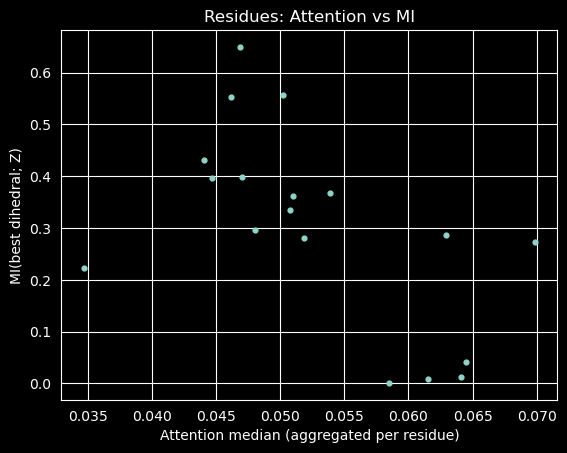

Wrote:
 - /home/tedeschg/prj/cvformer/cvformer-test/test08/output/cv_selection_independent/mi_phi_psi_vs_latent_recomputed.csv
 - /home/tedeschg/prj/cvformer/cvformer-test/test08/output/cv_selection_independent/combined_ranking_attention_mi.csv
 - /home/tedeschg/prj/cvformer/cvformer-test/test08/output/cv_selection_independent/selected_2_cvs.csv


In [44]:
plt.figure()
plt.scatter(merged["attn_median"], merged["best_mi"], s=12)
plt.xlabel("Attention median (aggregated per residue)")
plt.ylabel("MI(best dihedral; Z)")
plt.title("Residues: Attention vs MI")
plt.show()

out_dir = OUTPUT_DIR / "cv_selection_independent"
out_dir.mkdir(parents=True, exist_ok=True)

mi_df.to_csv(out_dir / "mi_phi_psi_vs_latent_recomputed.csv", index=False)
merged.to_csv(out_dir / "combined_ranking_attention_mi.csv", index=False)
cv2_df.to_csv(out_dir / "cv2_candidates_with_redundancy.csv", index=False)

pd.DataFrame([
    {"rank": 1, "resid": int(cv1["resid"]), "angle": cv1["best_angle"], "best_mi": cv1["best_mi"], "attn_median": cv1["attn_median"], "combined_score": cv1["combined_score"]},
    {"rank": 2, "resid": int(cv2["resid"]), "angle": cv2["angle"], "best_mi": cv2["best_mi"], "attn_median": cv2["attn_median"], "combined_score": cv2["combined_score"], "redundancy_mi": cv2["redundancy_mi"], "final_score": cv2["final_score"]},
]).to_csv(out_dir / "selected_2_cvs.csv", index=False)

print("Wrote:")
print(" -", (out_dir / "mi_phi_psi_vs_latent_recomputed.csv").resolve())
print(" -", (out_dir / "combined_ranking_attention_mi.csv").resolve())
print(" -", (out_dir / "selected_2_cvs.csv").resolve())
